## 1.Import Libraries and Load Cleaned Data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot
import seaborn as sns

#Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

#Models MachineLearning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from catboost import CatBoostClassifier

#module_function
from module_function import evalute_models, plot_confusion_matrix, plot_roc_curves, compare_models

sns.set_theme(style="whitegrid")
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")


In [16]:
df = pd.read_csv('dataset/fifa_player_performance_market_value_cleaned.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (2800, 25)


,age,nationality,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,...,avg_minutes_per_match,goals_per_90,assists_per_90,total_contributions,points_per_90,contract_expiry,contract_ration,career_phase,player_role_cluster,investment_class
0,23,4,8,65,87,8,6,14,2976,122.51,...,372.000000,0.181452,0.423387,20,0.604839,26,0.130435,3,1,3
1,36,2,8,90,76,19,3,18,2609,88.47,...,137.315789,0.103488,0.620928,21,0.724415,41,0.138889,1,1,2
2,31,3,6,75,91,34,12,15,1158,20.24,...,34.058824,0.932642,1.165803,27,2.098446,34,0.096774,1,2,1
3,27,6,5,90,86,35,18,13,145,164.29,...,4.142857,11.172414,8.068966,31,19.241379,27,0.000000,0,0,0
4,24,1,1,84,96,41,6,6,2226,121.34,...,54.292683,0.242588,0.242588,12,0.485175,28,0.166667,3,2,2


## 2.Prepare Feature and Target

In [17]:
df_x = df.drop(columns='transfer_risk_level')
df_y = df['transfer_risk_level']

print(f"Features shape: {df_x.shape}")
print(f"Target distribution:\n{df_y.value_counts()}")
print(f"\nFeature columns: {df_x.columns.tolist()}")

Features shape: (2800, 24)
Target distribution:
transfer_risk_level
1    1250
2     991
0     559
Name: count, dtype: int64

Feature columns: ['age', 'nationality', 'position', 'overall_rating', 'potential_rating', 'matches_played', 'goals', 'assists', 'minutes_played', 'market_value_million_eur', 'contract_years_left', 'injury_prone', 'growth_dynamic', 'growth_percentage', 'avg_minutes_per_match', 'goals_per_90', 'assists_per_90', 'total_contributions', 'points_per_90', 'contract_expiry', 'contract_ration', 'career_phase', 'player_role_cluster', 'investment_class']


In [18]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42,stratify=df_y)

print(f"Training set: {X_train.shape[0]} samples rows")
print(f"Test set: {X_test.shape[0]} samples rows")

train_prop = y_train.value_counts(normalize=True) * 100
test_prop = y_test.value_counts(normalize=True) * 100

print("\n--- Training Level Risk Rate per Kategori ---")
for kategori, persentase in train_prop.items():
    print(f"{kategori}: {persentase:.2f}%")

print("\n--- Test Level Risk Rate per Kategori ---")
for kategori, persentase in test_prop.items():
    print(f"{kategori}: {persentase:.2f}%")


Training set: 2240 samples rows
Test set: 560 samples rows

--- Training Level Risk Rate per Kategori ---
1: 44.64%
2: 35.40%
0: 19.96%

--- Test Level Risk Rate per Kategori ---
1: 44.64%
2: 35.36%
0: 20.00%


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#convert back to Dataframe
X_train_scaled  = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

print("Scaling complete. First 3 rows of scaled training data:")
X_train_scaled.head(3)

Scaling complete. First 3 rows of scaled training data:


,age,nationality,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,...,avg_minutes_per_match,goals_per_90,assists_per_90,total_contributions,points_per_90,contract_expiry,contract_ration,career_phase,player_role_cluster,investment_class
2689,-0.277002,0.667609,1.168729,0.322562,-0.366248,-1.314293,-1.566634,0.004212,-0.257770,1.190453,...,0.270438,-0.131339,-0.117491,-1.322491,-0.129317,-0.490440,-0.811693,-1.402730,-0.072149,0.148198
2433,0.168748,1.104745,0.005711,-0.488140,-0.879700,-1.565334,-0.965821,-0.689503,0.096204,-0.197070,...,2.179554,-0.121405,-0.139675,-1.177340,-0.130437,0.089288,-0.385695,0.415624,-0.072149,0.148198
1290,-0.277002,0.667609,0.393384,-0.690816,1.071420,0.505752,0.407464,-1.521961,-1.024839,-1.158672,...,-0.373144,-0.041420,-0.152037,-0.451587,-0.081123,-0.635372,-1.348819,-1.402730,-1.582552,1.338033


In [20]:
all_predictions = {}
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'K-Neighbors': KNeighborsClassifier(),
    'SVM': SVC(),
    'XGBoost': XGBClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'CatBoost':CatBoostClassifier(verbose=0, random_state=42)
}
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred = model.predict(X_test_scaled)
    all_predictions[name] = y_pred

df_hasil = evalute_models(all_predictions,y_test,averages='macro')
df_hasil

=== CLASSIFICATION REPORT: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       112
           1       0.46      0.84      0.59       250
           2       0.38      0.19      0.26       198

    accuracy                           0.44       560
   macro avg       0.28      0.35      0.28       560
weighted avg       0.34      0.44      0.36       560



=== CLASSIFICATION REPORT: Decision Tree ===
              precision    recall  f1-score   support

           0       0.19      0.17      0.18       112
           1       0.46      0.49      0.47       250
           2       0.42      0.40      0.41       198

    accuracy                           0.40       560
   macro avg       0.36      0.36      0.35       560
weighted avg       0.39      0.40      0.39       560



=== CLASSIFICATION REPORT: Random Forest ===
              precision    recall  f1-score   support

           0       0.25      0.02     

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.444643,0.280513,0.345306,0.283141
1,Decision Tree,0.396429,0.355307,0.355228,0.354873
2,Random Forest,0.417857,0.352322,0.334545,0.297457
3,Gradient Boosting,0.371429,0.255857,0.295434,0.261305
4,K-Neighbors,0.369643,0.312608,0.316400,0.307345
5,SVM,0.433929,0.277384,0.339407,0.284630
6,XGBoost,0.400000,0.321128,0.331285,0.314060
7,AdaBoost,0.451786,0.284602,0.349239,0.281469
8,CatBoost,0.405357,0.349653,0.339621,0.325124


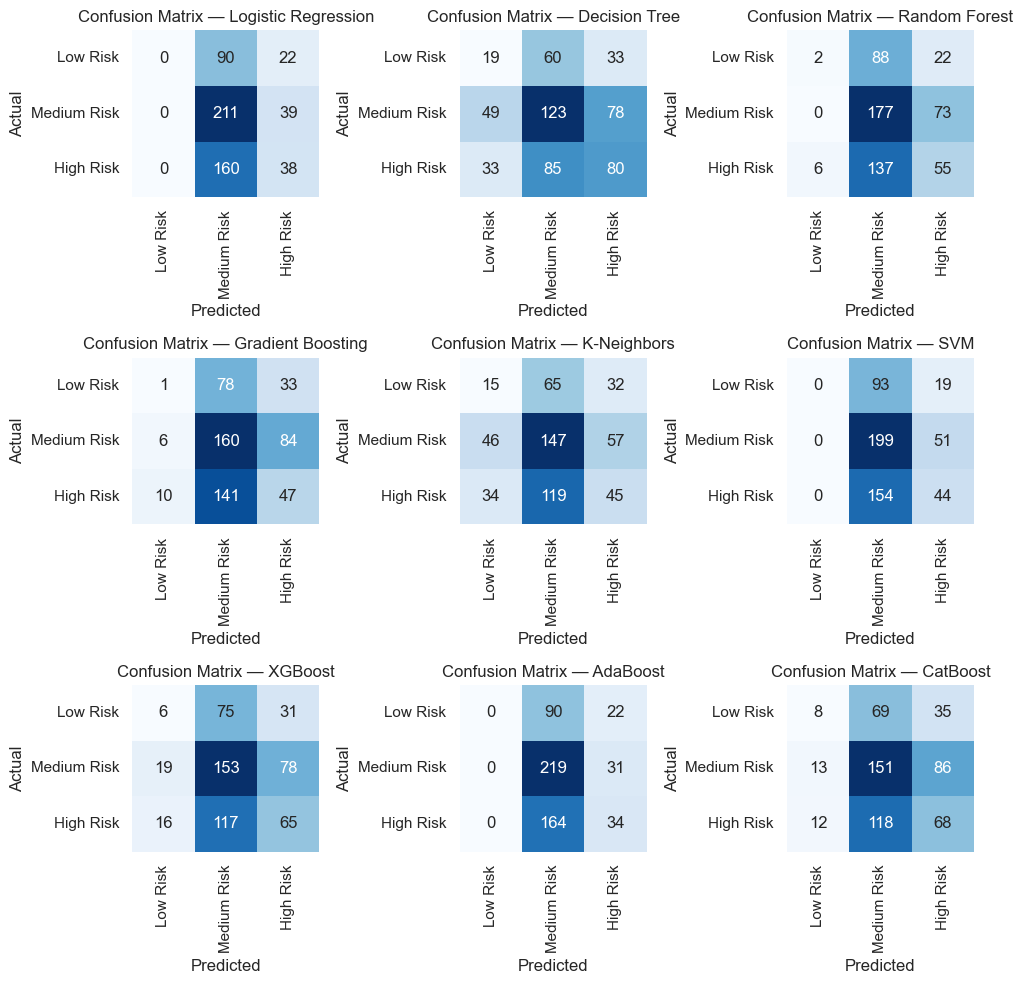

In [21]:
plot_confusion_matrix(all_predictions,y_test,labels=["Low Risk", "Medium Risk", "High Risk"])